## Project environment

In [3]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import numpy as np

# Project root (current working) directory
project_root = Path.cwd().parent

# Define project directory
data_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"

## Load processed data

In [4]:
processed_data = "invoice_df_processed.parquet" # Processed data filename
processed_df = pd.read_parquet(processed_dir / processed_data) # Read Parquet file

## Supplier level aggregation

In [5]:
# Aggregate the data on supplier level
agg_df = processed_df.groupby("supplier_id").agg(
    supplier_name=("supplier_name", "first"),
    total_spend=("invoice_amount", "sum"),
    avg_invoice_amount=("invoice_amount", "mean"),
    total_invoices=("invoice_number", "count")
).sort_values("total_spend", ascending=False).reset_index()

## Distribution analysis

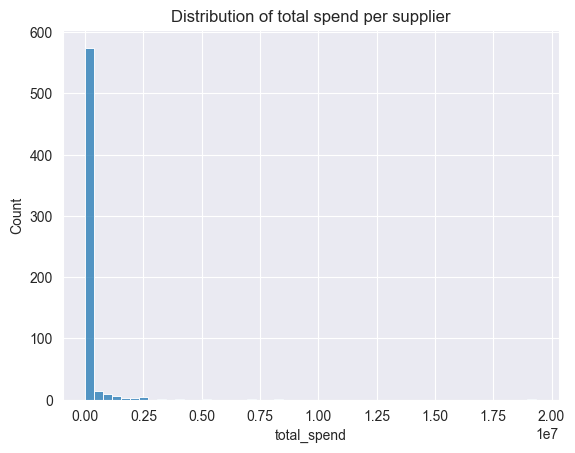

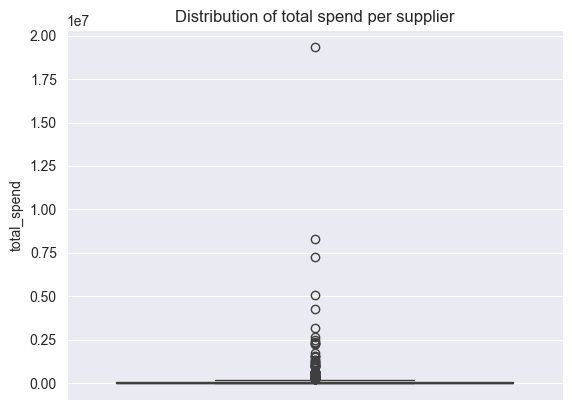

In [6]:
# =============================================================================
# NOTE:
# The distribution of total invoice amount and number of invoices per supplier
# is highly right-skewed. This indicates that a small number of suppliers
# account for a large share of total spend. These suppliers may have a significant
# effect on the segmentation model. Therefore, a log transformation is applied to
# reduce skewness and improve interpretability.
# =============================================================================

'''Distribution of total invoice amount (spend)'''

# Histogram
plt.figure()
sns.histplot(data=agg_df, x="total_spend")
plt.title("Distribution of total spend per supplier")
plt.show()

# Boxplot
plt.figure()
sns.boxplot(data=agg_df, y="total_spend")
plt.title("Distribution of total spend per supplier")
plt.show()

## Log-transformation

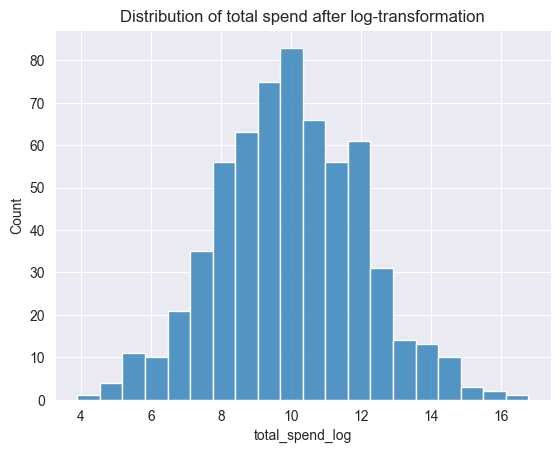

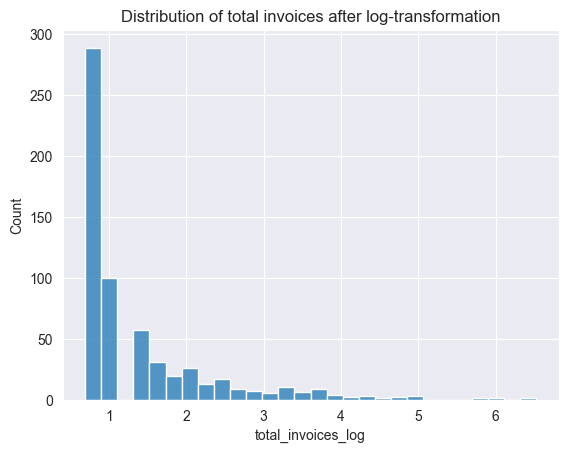

In [7]:
# Remove suppliers with a total spend < 0 (required before log_transformation)
agg_df = agg_df[(agg_df["total_spend"] > 0)].copy()

# Apply log-transformations
agg_df["total_spend_log"] = np.log1p(agg_df["total_spend"])
agg_df["total_invoices_log"] = np.log1p(agg_df["total_invoices"])
agg_df["avg_invoice_amount"] = np.log1p(agg_df["avg_invoice_amount"])

# Distribution of total spend after log-transformation
plt.figure()
sns.histplot(data=agg_df, x='total_spend_log')
plt.title("Distribution of total spend after log-transformation")
plt.show()

# Distribution of total number of invoices after log-transformation
plt.figure()
sns.histplot(data=agg_df, x='total_invoices_log')
plt.title("Distribution of total invoices after log-transformation")
plt.show()

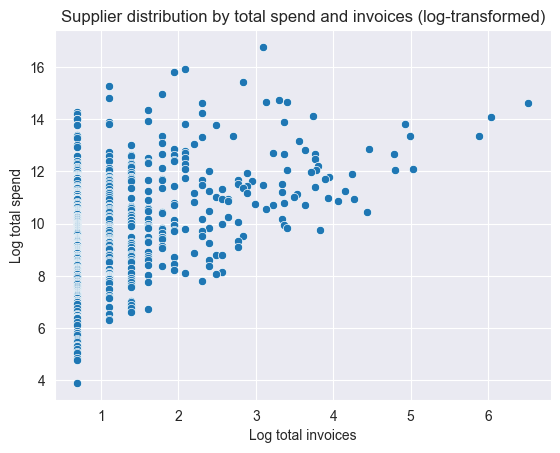

In [8]:
plt.figure()

sns.scatterplot(data=agg_df, x="total_invoices_log", y="total_spend_log")
plt.title("Supplier distribution by total spend and invoices (log-transformed)")
plt.xlabel("Log total invoices")
plt.ylabel("Log total spend")
plt.show()

## Save aggregated data

In [9]:
output_file = 'aggregated_supplier_df.parquet'
agg_df.to_parquet(processed_dir / output_file, index=False) # Save as Parquet